In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import beorn
import tools21cm as t2c

In [2]:
SCRATCH_ROOT = Path("/xdisk/timeifler/yhhuang/BEoRN-v2/")
FILE_ROOT = Path("/xdisk/timeifler/yhhuang/Thesan/")
CACHE_ROOT = SCRATCH_ROOT / "thesan_run_fstar" / "cache"
PARAMETER_FILE = Path("parameters_fstar.yaml")

In [3]:
parameters = beorn.structs.Parameters.from_yaml(PARAMETER_FILE)
parameters.simulation.file_root = FILE_ROOT
parameters.solver.redshifts = np.sort(parameters.solver.redshifts)

cache_handler = beorn.io.Handler(CACHE_ROOT)

cache_namespace = "painted_output_fstar_dist_lognormal_sigma_0.1_seed_12345"

loaded z = 15.200209617614746
xHII shape = (512, 512, 512)


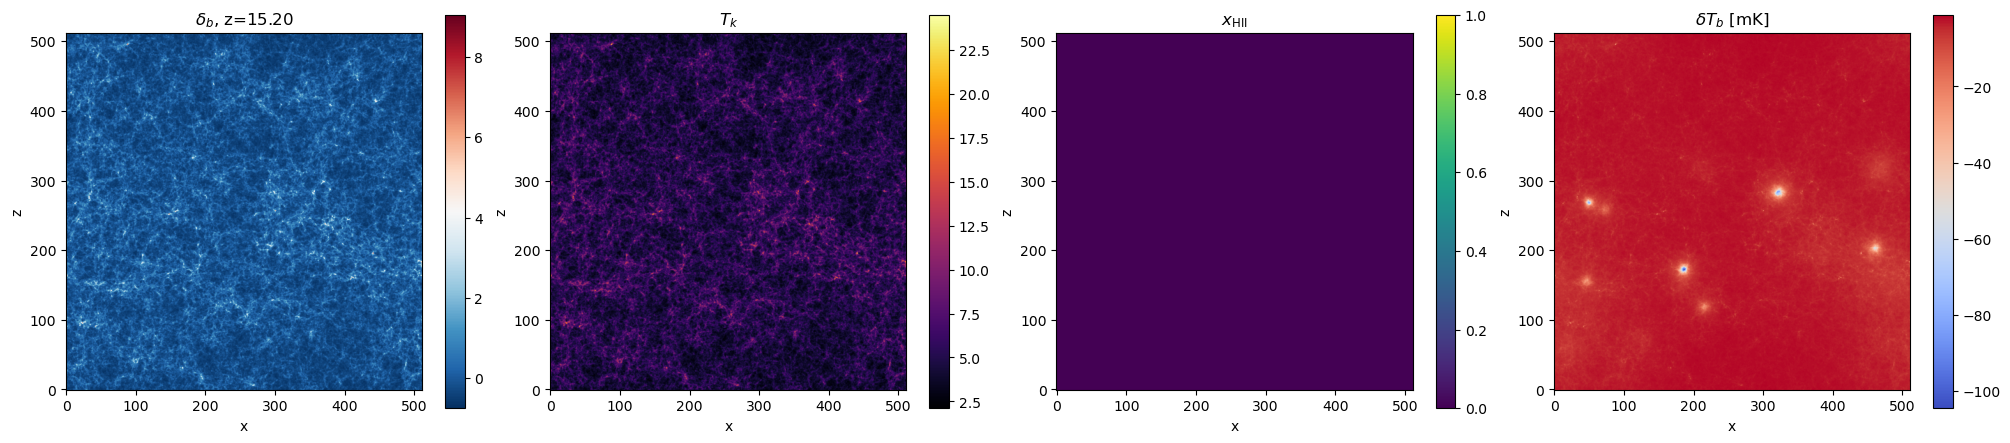

In [4]:
z_index = 8
grid = cache_handler.load_file(
    parameters,
    beorn.structs.CoevalCube,
    z_index=z_index,
    cache_namespace=cache_namespace,
)

print("loaded z =", float(grid.z))
print("xHII shape =", grid.Grid_xHII.shape)

slice_index = grid.Grid_xHII.shape[1] // 2

fig, axs = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)

im0 = axs[0].imshow(grid.delta_b[:, slice_index, :], origin="lower", cmap="RdBu_r")
axs[0].set_title(rf"$\delta_b$, z={grid.z:.2f}")
plt.colorbar(im0, ax=axs[0], shrink=0.8)

im1 = axs[1].imshow(grid.Grid_Temp[:, slice_index, :], origin="lower", cmap="inferno")
axs[1].set_title(r"$T_k$")
plt.colorbar(im1, ax=axs[1], shrink=0.8)

im2 = axs[2].imshow(grid.Grid_xHII[:, slice_index, :], origin="lower", cmap="viridis", vmin=0, vmax=1)
axs[2].set_title(r"$x_{\rm HII}$")
plt.colorbar(im2, ax=axs[2], shrink=0.8)

# Grid_dTb is derived from the cached base grids on demand
im3 = axs[3].imshow(grid.Grid_dTb[:, slice_index, :], origin="lower", cmap="coolwarm")
axs[3].set_title(r"$\delta T_b$ [mK]")
plt.colorbar(im3, ax=axs[3], shrink=0.8)

for ax in axs:
    ax.set_xlabel("x")
    ax.set_ylabel("z")

plt.show()


In [5]:
# z = grid.z
# Tk = np.asarray(grid.Grid_Temp)
# xHII = np.asarray(grid.Grid_xHII)
# xal = np.asarray(grid.Grid_xal)
# xcoll = np.asarray(grid.Grid_xcoll)
# delta_b = np.asarray(grid.delta_b)

In [6]:
# dTb = beorn.cosmo.dTb_factor(parameters) * np.sqrt(1+z) \
#     * (1 - beorn.cosmo.T_cmb(z) / Tk) * (1 - xHII) * (xal + xcoll) / xcoll * (1 + delta_b)


In [7]:
# fig, axs = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
# im1 = axs[0].imshow(grid.Grid_dTb[:, slice_index, :], origin="lower", cmap="coolwarm")
# axs[0].set_title(r"$\delta T_b$ [mK]")
# plt.colorbar(im1, ax=axs[0], shrink=0.8)

# im2 = axs[1].imshow(dTb[:, slice_index, :], origin="lower", cmap="coolwarm")
# axs[1].set_title(r"$\delta T_b$ [mK]")
# plt.colorbar(im1, ax=axs[1], shrink=0.8)

# for ax in axs:
#     ax.set_xlabel("x")
#     ax.set_ylabel("z")

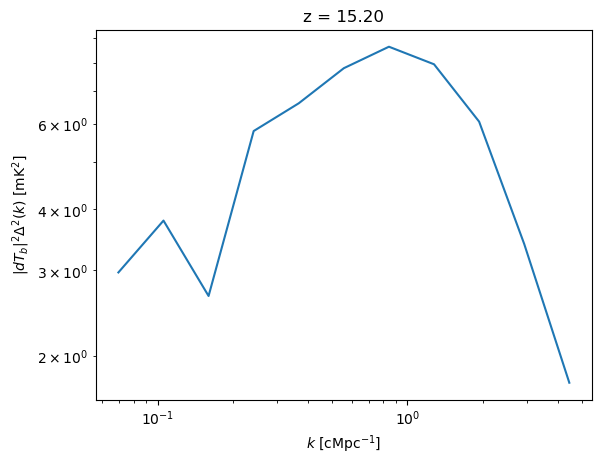

In [9]:
dTb = np.asarray(grid.Grid_dTb)
mean_dTb = np.mean(dTb)
delta_dTb = dTb / mean_dTb - 1
kbins = parameters.simulation.kbins
box_dims = parameters.simulation.Lbox

ps, bins = t2c.power_spectrum_1d(
    delta_dTb,
    box_dims=box_dims,
    kbins=kbins
)
ps_dimless = ps * bins**3 * mean_dTb**2 / (2 * np.pi**2)

plt.figure()
plt.loglog(bins, ps_dimless)
plt.xlabel(r"$k$ [cMpc$^{-1}$]")
plt.ylabel(r"$|dT_b|^2 \Delta^2(k)$ [mK$^2$]")
plt.title(rf"z = {grid.z:.2f}")
plt.show()

In [10]:
z_list = []
temp_mean = []
xhii_mean = []
xal_mean = []
dtb_mean = []

for z_index in range(12):
    try:
        snap = cache_handler.load_file(
            parameters,
            beorn.structs.CoevalCube,
            z_index=z_index,
            cache_namespace=cache_namespace,
        )
    except FileNotFoundError:
        break

    z_list.append(float(snap.z))
    temp_mean.append(np.mean(snap.Grid_Temp))
    xhii_mean.append(np.mean(snap.Grid_xHII))
    xal_mean.append(np.mean(snap.Grid_xal))

    # computes dTb for this snapshot only, then immediately averages it
    dtb_mean.append(np.mean(snap.Grid_dTb))

z = np.array(z_list)
temp_mean = np.array(temp_mean)
xhii_mean = np.array(xhii_mean)
xal_mean = np.array(xal_mean)
dtb_mean = np.array(dtb_mean)

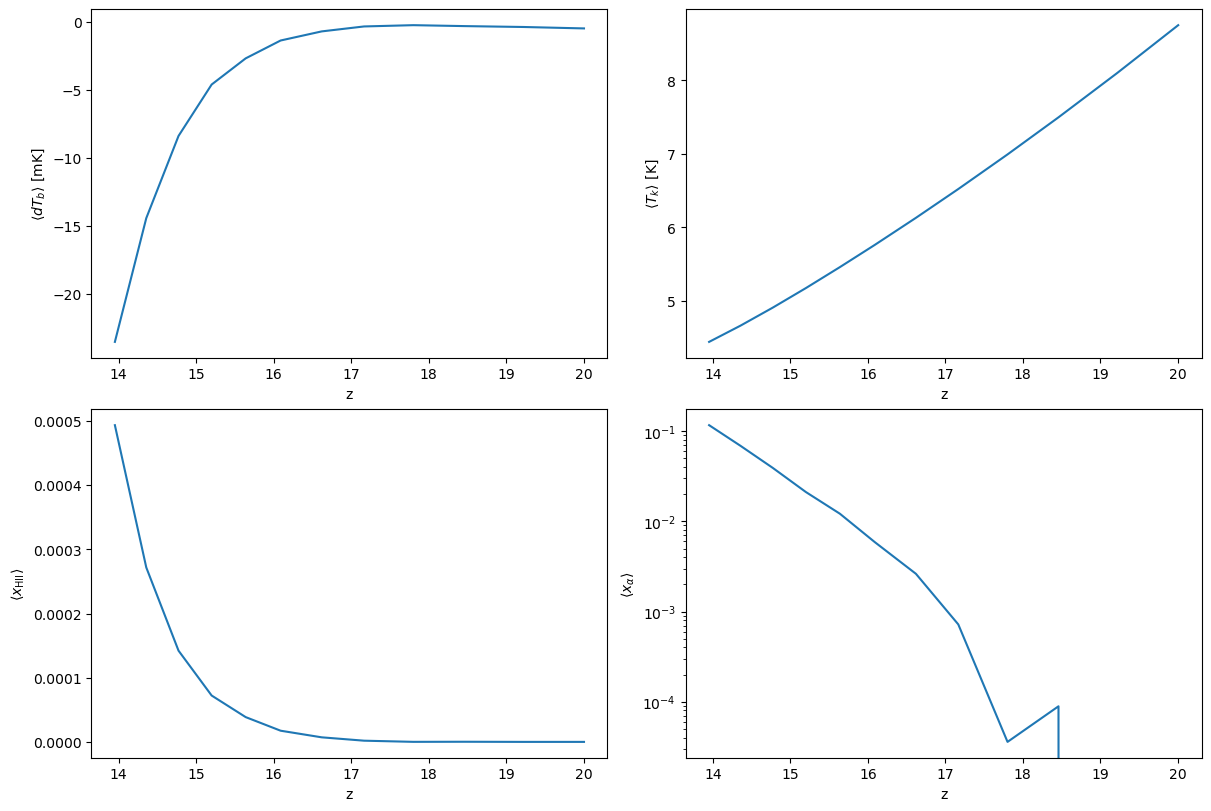

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axs[0, 0].plot(z, dtb_mean)
axs[0, 0].set_xlabel("z")
axs[0, 0].set_ylabel(r"$\langle dT_b \rangle$ [mK]")

axs[0, 1].plot(z, temp_mean)
axs[0, 1].set_xlabel("z")
axs[0, 1].set_ylabel(r"$\langle T_k \rangle$ [K]")

axs[1, 0].plot(z, xhii_mean)
axs[1, 0].set_xlabel("z")
axs[1, 0].set_ylabel(r"$\langle x_{\mathrm{HII}} \rangle$")

axs[1, 1].semilogy(z, xal_mean)
axs[1, 1].set_xlabel("z")
axs[1, 1].set_ylabel(r"$\langle x_\alpha \rangle$")

plt.show()